In [1]:
import lsdb
from lsdb.streams import CatalogStream, InfiniteStream
import numpy as np
import nested_pandas as npd
import dask.dataframe as dd
from dask.distributed import Client
import time
import tracemalloc
import gc
import resource
import pandas as pd

# Streaming with Operations
Currently in the Operations branch, Catalog Streaming involves a full graph build on initialization, removing it's advantage of lessened graph pressure. This notebook started out as an investigation of that, but has since turned into a notebook demonstrating some experimental changes to operations and streaming that improves this.

### Brief Reminder on CatalogStreams

In [5]:
from lsdb.streams import CatalogStream

cat2 = lsdb.open_catalog("catalogs/catalog2/generated_catalog")
cat2_stream = CatalogStream(cat2, partitions_per_chunk=3)

for chunk in cat2_stream:
    print(len(chunk))

1058
1389
1980
573


## Setup

In [6]:
cat7 = lsdb.open_catalog("catalogs/catalog7/generated_catalog")
cat2 = lsdb.open_catalog("catalogs/catalog2/generated_catalog")
cat3 = lsdb.open_catalog("catalogs/catalog3/generated_catalog")
cat4 = lsdb.open_catalog("catalogs/catalog4/generated_catalog")
cat8 = lsdb.open_catalog("catalogs/catalog8/generated_catalog")

In [7]:
def report_performance(catalog, n_workers, partitions_per_chunk, memory_limit="3GB"):
    print(f"number of workers: {n_workers}")
    print(f"partitions_per_chunk (streaming): {partitions_per_chunk}")
    results = {}

    with Client(threads_per_worker=1, n_workers=n_workers, dashboard_address=":8325", memory_limit=memory_limit) as client:
        time0 = time.time()
        catalog.compute()
        time1 = time.time()
    results["Compute/Client"] = time1 - time0

    with Client(threads_per_worker=1, n_workers=n_workers, dashboard_address=":8325", memory_limit=memory_limit) as client:
        stream = CatalogStream(catalog, partitions_per_chunk=partitions_per_chunk, shuffle=False)
        time0 = time.time()
        for chunk in stream:
            chunk
        time1 = time.time()
    results["Stream/Client"] = time1 - time0

    time0 = time.time()
    catalog.compute()
    time1 = time.time()
    results["Compute/NoClient"] = time1 - time0

    stream = CatalogStream(catalog, partitions_per_chunk=partitions_per_chunk, shuffle=False)
    time0 = time.time()
    for chunk in stream:
        chunk
    time1 = time.time()
    results["Stream/NoClient"] = time1 - time0

    return results

def collate_performance(catalog, n_workers_list, partitions_per_chunk_list, memory_limit="3GB"):
    all_results = {}

    # NoClient doesn't depend on n_workers, so only run it once
    for partitions_per_chunk in partitions_per_chunk_list:
        print(f"\n--- Running NoClient: partitions_per_chunk={partitions_per_chunk} ---")
        time0 = time.time()
        catalog.compute()
        time1 = time.time()
        compute_noclient = time1 - time0

        stream = CatalogStream(catalog, partitions_per_chunk=partitions_per_chunk, shuffle=False)
        time0 = time.time()
        for chunk in stream:
            chunk
        time1 = time.time()
        stream_noclient = time1 - time0

        all_results[(None, partitions_per_chunk)] = {
            "Compute/NoClient": compute_noclient,
            "Stream/NoClient": stream_noclient,
        }

    # Client results depend on both n_workers and partitions_per_chunk
    for n_workers in n_workers_list:
        for partitions_per_chunk in partitions_per_chunk_list:
            print(f"\n--- Running Client: n_workers={n_workers}, partitions_per_chunk={partitions_per_chunk} ---")

            with Client(threads_per_worker=1, n_workers=n_workers, dashboard_address=":8325", memory_limit=memory_limit) as client:
                time0 = time.time()
                catalog.compute()
                time1 = time.time()
                compute_client = time1 - time0

            with Client(threads_per_worker=1, n_workers=n_workers, dashboard_address=":8325", memory_limit=memory_limit) as client:
                stream = CatalogStream(catalog, partitions_per_chunk=partitions_per_chunk, shuffle=False)
                time0 = time.time()
                for chunk in stream:
                    chunk
                time1 = time.time()
                stream_client = time1 - time0

            all_results[(n_workers, partitions_per_chunk)] = {
                "Compute/Client": compute_client,
                "Stream/Client": stream_client,
            }

    return all_results

def plot_collated_results(all_results):
    import pandas as pd
    import matplotlib.pyplot as plt

    client_rows, noclient_rows = [], []
    for (n_workers, partitions_per_chunk), metrics in all_results.items():
        row = {"partitions_per_chunk": partitions_per_chunk, **metrics}
        if n_workers is None:
            noclient_rows.append(row)
        else:
            client_rows.append({"n_workers": n_workers, **row})

    client_df = pd.DataFrame(client_rows)
    noclient_df = pd.DataFrame(noclient_rows).sort_values("partitions_per_chunk")

    n_workers_vals = sorted(client_df["n_workers"].unique())
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
    fig.suptitle("`open_catalog` Performance Results", fontsize=14, fontweight="bold")

    # --- Client plot ---
    ax = axes[0]
    ax.set_title("Distributed Client")
    for i, n_workers in enumerate(n_workers_vals):
        color = prop_cycle[i % len(prop_cycle)]
        subset = client_df[client_df["n_workers"] == n_workers].sort_values("partitions_per_chunk")
        ax.plot(subset["partitions_per_chunk"], subset["Stream/Client"], marker="o",
                color=color, label=f"Stream ({n_workers} workers)")
        compute_mean = subset["Compute/Client"].mean()
        ax.axhline(compute_mean, color=color, linestyle="--",
                   label=f"Compute mean ({n_workers} workers)")

    ax.set_xlabel("partitions_per_chunk")
    ax.set_ylabel("Time (s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- NoClient plot ---
    ax = axes[1]
    ax.set_title("Local Cluster (No Client)")
    color = prop_cycle[0]
    ax.plot(noclient_df["partitions_per_chunk"], noclient_df["Stream/NoClient"], marker="o",
            color=color, label="Stream")
    compute_mean = noclient_df["Compute/NoClient"].mean()
    ax.axhline(compute_mean, color=color, linestyle="--", label="Compute mean")

    ax.set_xlabel("partitions_per_chunk")
    ax.set_ylabel("Time (s)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig

## Performance Comparison vs Compute 

### Opening a Catalog


--- Running NoClient: partitions_per_chunk=1 ---


Computing Catalog:   0%|          | 0/792 [00:00<?, ?it/s]


--- Running NoClient: partitions_per_chunk=3 ---


Computing Catalog:   0%|          | 0/792 [00:00<?, ?it/s]


--- Running NoClient: partitions_per_chunk=9 ---


...


--- Running NoClient: partitions_per_chunk=100 ---


Computing Catalog:   0%|          | 0/792 [00:00<?, ?it/s]


--- Running Client: n_workers=1, partitions_per_chunk=1 ---

--- Running Client: n_workers=1, partitions_per_chunk=3 ---

--- Running Client: n_workers=1, partitions_per_chunk=9 ---

--- Running Client: n_workers=1, partitions_per_chunk=27 ---

--- Running Client: n_workers=1, partitions_per_chunk=100 ---

--- Running Client: n_workers=3, partitions_per_chunk=1 ---

--- Running Client: n_workers=3, partitions_per_chunk=3 ---

--- Running Client: n_workers=3, partitions_per_chunk=9 ---

--- Running Client: n_workers=3, partitions_per_chunk=27 ---

--- Running Client: n_workers=3, partitions_per_chunk=100 ---

--- Running Client: n_workers=9, partitions_per_chunk=1 ---

--- Running Client: n_workers=9, partitions_per_chunk=3 ---

--- Running Client: n_workers=9, partitions_per_chunk=9 ---


2026-07-01 08:42:14,776 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distributed/worker.py", line 1273, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
  File "/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distrib


--- Running Client: n_workers=9, partitions_per_chunk=27 ---

--- Running Client: n_workers=9, partitions_per_chunk=100 ---


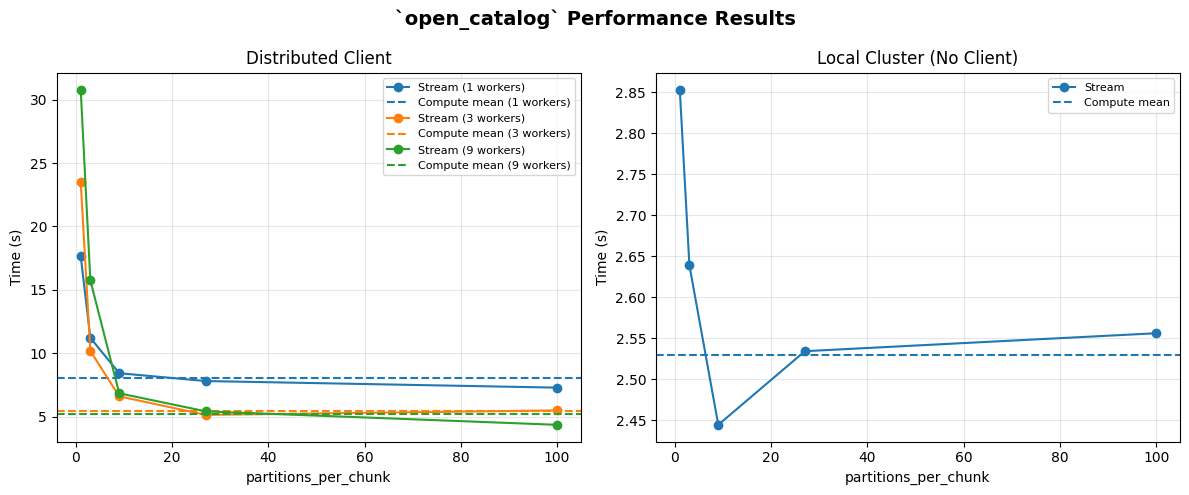

,ra,dec,id,a,b,nested
npartitions=792,,,,,,
"Order: 4, Pixel: 0",double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],"nested<t: [double], flux: [double], band: [str..."
"Order: 4, Pixel: 1",...,...,...,...,...,...
...,...,...,...,...,...,...
"Order: 4, Pixel: 1790",...,...,...,...,...,...
"Order: 4, Pixel: 1791",...,...,...,...,...,...


In [9]:
results = collate_performance(cat7, n_workers_list=[1,3,9], partitions_per_chunk_list=[1, 3, 9, 27, 100])
fig = plot_collated_results(results)
cat7

### Performing a Crossmatch

/Users/dbranton/lincc/lsdb/src/lsdb/catalog/catalog.py:409: FutureWarning: The default suffix behavior will change from applying suffixes to all columns to only applying suffixes to overlapping columns in a future release.To maintain the current behavior, explicitly set `suffix_method='all_columns'`. To change to the new behavior, set `suffix_method='overlapping_columns'`.
  warnings.warn(
/Users/dbranton/lincc/lsdb/src/lsdb/operations/functions/crossmatch_catalog_data.py:351: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(



--- Running NoClient: partitions_per_chunk=1 ---


Computing Catalog:   0%|          | 0/724 [00:00<?, ?it/s]


--- Running NoClient: partitions_per_chunk=3 ---


Computing Catalog:   0%|          | 0/724 [00:00<?, ?it/s]

...

Computing Catalog:   0%|          | 0/724 [00:00<?, ?it/s]


--- Running NoClient: partitions_per_chunk=100 ---


Computing Catalog:   0%|          | 0/724 [00:00<?, ?it/s]


--- Running Client: n_workers=1, partitions_per_chunk=1 ---

--- Running Client: n_workers=1, partitions_per_chunk=3 ---

--- Running Client: n_workers=1, partitions_per_chunk=9 ---

--- Running Client: n_workers=1, partitions_per_chunk=27 ---

--- Running Client: n_workers=1, partitions_per_chunk=100 ---

--- Running Client: n_workers=3, partitions_per_chunk=1 ---

--- Running Client: n_workers=3, partitions_per_chunk=3 ---

--- Running Client: n_workers=3, partitions_per_chunk=9 ---

--- Running Client: n_workers=3, partitions_per_chunk=27 ---

--- Running Client: n_workers=3, partitions_per_chunk=100 ---

--- Running Client: n_workers=9, partitions_per_chunk=1 ---

--- Running Client: n_workers=9, partitions_per_chunk=3 ---

--- Running Client: n_workers=9, partitions_per_chunk=9 ---

--- Running Client: n_workers=9, partitions_per_chunk=27 ---

--- Running Client: n_workers=9, partitions_per_chunk=100 ---


2026-07-01 08:48:54,622 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distributed/worker.py", line 1273, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
  File "/Users/dbranton/.virtualenvs/lsdb/lib/python3.12/site-packages/distrib

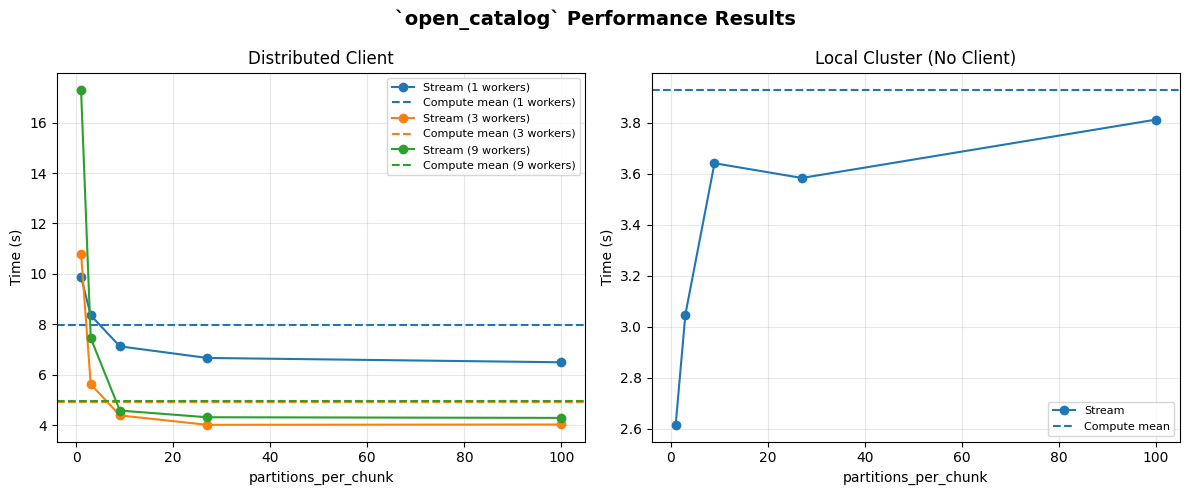

In [10]:
# Crossmatch
results = collate_performance(cat3.crossmatch(cat4, suffixes=("_l","_r")).query("ra_l>20"), n_workers_list=[1,3,9], partitions_per_chunk_list=[1, 3, 9, 27, 100])
fig = plot_collated_results(results)

## Streaming: Iter Graph Chunk Sizes

In [5]:
catstream = iter(CatalogStream(cat2, log_graph_size=True)) # log_graph_size is a temp kwarg
for i in range(10):
    next(catstream)

chunk graph: 4,814 bytes  (1 tasks)
chunk graph: 4,814 bytes  (1 tasks)
chunk graph: 4,814 bytes  (1 tasks)
chunk graph: 4,814 bytes  (1 tasks)
chunk graph: 4,814 bytes  (1 tasks)
chunk graph: 4,814 bytes  (1 tasks)
chunk graph: 4,814 bytes  (1 tasks)
chunk graph: 4,814 bytes  (1 tasks)
chunk graph: 4,814 bytes  (1 tasks)
chunk graph: 4,814 bytes  (1 tasks)
chunk graph: 4,814 bytes  (1 tasks)


In [5]:
# vs compute
CatalogStream(cat2).show_graph_size_DEBUG()

full graph: 44,217 bytes  (12 tasks)


In [6]:
catstream = iter(CatalogStream(cat3.crossmatch(cat4, suffixes=("_l","_r")).query("ra_l>20"), log_graph_size=True))
for i in range(10):
    next(catstream)

/Users/dbranton/lincc/lsdb/src/lsdb/catalog/catalog.py:409: FutureWarning: The default suffix behavior will change from applying suffixes to all columns to only applying suffixes to overlapping columns in a future release.To maintain the current behavior, explicitly set `suffix_method='all_columns'`. To change to the new behavior, set `suffix_method='overlapping_columns'`.
  warnings.warn(
/Users/dbranton/lincc/lsdb/src/lsdb/operations/functions/crossmatch_catalog_data.py:351: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(


chunk graph: 36,851 bytes  (4 tasks)
chunk graph: 36,777 bytes  (4 tasks)
chunk graph: 15,202 bytes  (4 tasks)
chunk graph: 36,766 bytes  (4 tasks)
chunk graph: 15,080 bytes  (4 tasks)
chunk graph: 36,916 bytes  (4 tasks)
chunk graph: 36,855 bytes  (4 tasks)
chunk graph: 36,732 bytes  (4 tasks)
chunk graph: 36,654 bytes  (4 tasks)
chunk graph: 36,858 bytes  (4 tasks)
chunk graph: 36,858 bytes  (4 tasks)


In [6]:
CatalogStream(cat3.crossmatch(cat4, suffixes=("_l","_r")).query("ra_l>20")).show_graph_size_DEBUG()

/Users/dbranton/lincc/lsdb/src/lsdb/catalog/catalog.py:409: FutureWarning: The default suffix behavior will change from applying suffixes to all columns to only applying suffixes to overlapping columns in a future release.To maintain the current behavior, explicitly set `suffix_method='all_columns'`. To change to the new behavior, set `suffix_method='overlapping_columns'`.
  warnings.warn(
/Users/dbranton/lincc/lsdb/src/lsdb/operations/functions/crossmatch_catalog_data.py:351: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(


full graph: 4,388,662 bytes  (724 tasks)


## Result Verification

In [12]:
crossmatch = cat3.crossmatch(cat4, suffixes=("_l","_r")).query("ra_l>20")
catstream = iter(CatalogStream(crossmatch, shuffle=False))

compute_res = crossmatch.compute()

chunks = []
for chunk in catstream:
    chunks.append(chunk)

import pandas as pd
stream_res = pd.concat(chunks)

/Users/dbranton/lincc/lsdb/src/lsdb/catalog/catalog.py:409: FutureWarning: The default suffix behavior will change from applying suffixes to all columns to only applying suffixes to overlapping columns in a future release.To maintain the current behavior, explicitly set `suffix_method='all_columns'`. To change to the new behavior, set `suffix_method='overlapping_columns'`.
  warnings.warn(
/Users/dbranton/lincc/lsdb/src/lsdb/operations/functions/crossmatch_catalog_data.py:351: RuntimeWarning: Right catalog does not have a margin cache. Results may be incomplete and/or inaccurate.
  warnings.warn(


Computing Catalog:   0%|          | 0/724 [00:00<?, ?it/s]

In [27]:
compute_res.sort_index()

ra_l      dec_l   id_l       a_l       b_l  \
_healpix_29                                                           
158586511478911509  22.748983  34.233318  48338  0.958605  1.226599   
158605311949239354  22.896529  34.599695  20469  0.960778  0.609081   
...                       ...        ...    ...       ...       ...   
198375868650385855  21.846904  43.839605  30852  0.962172  1.641197   
198453155610554333   23.05652  43.864715  27934   0.97481  0.256227   

                                                             nested_l  \
_healpix_29                                                             
158586511478911509  [{t: 0.351339, flux: 7.80264, band: 'g', flux_...   
158605311949239354  [{t: 11.548406, flux: 15.167234, band: 'g', fl...   
...                                                               ...   
198375868650385855  [{t: 11.413478, flux: 70.808575, band: 'g', fl...   
198453155610554333  [{t: 7.295795, flux: 60.170066, band: 'r', flu...   

                         ra_r      dec_r   id_r       a_r       b_r  \
_healpix_29                                                           
158586511478911509  22.748983  34.233318  48338  0.958605  1.226599   
158605311949239354  22.896529  34.599695  20469  0.960778  0.609081   
...                       ...        ...    ...       ...       ...   
198375868650385855  21.846904  43.839605  30852  0.962172  1.641197   
198453155610554333   23.05652  43.864715  27934   0.97481  0.256227   

                                                             nested_r  \
_healpix_29                                                             
158586511478911509  [{t: 0.351339, flux: 7.80264, band: 'g', flux_...   
158605311949239354  [{t: 11.548406, flux: 15.167234, band: 'g', fl...   
...                                                               ...   
198375868650385855  [{t: 11.413478, flux: 70.808575, band: 'g', fl...   
198453155610554333  [{t: 7.295795, flux: 60.170066, band: 'r', flu...   

                    _dist_arcsec  
_healpix_29                       
158586511478911509           0.0  
158605311949239354           0.0  
...                          ...  
198375868650385855           0.0  
198453155610554333           0.0  

[104 rows x 13 columns]

In [28]:
stream_res.sort_index()

ra_l      dec_l   id_l       a_l       b_l  \
_healpix_29                                                           
158586511478911509  22.748983  34.233318  48338  0.958605  1.226599   
158605311949239354  22.896529  34.599695  20469  0.960778  0.609081   
...                       ...        ...    ...       ...       ...   
198375868650385855  21.846904  43.839605  30852  0.962172  1.641197   
198453155610554333   23.05652  43.864715  27934   0.97481  0.256227   

                                                             nested_l  \
_healpix_29                                                             
158586511478911509  [{t: 0.351339, flux: 7.80264, band: 'g', flux_...   
158605311949239354  [{t: 11.548406, flux: 15.167234, band: 'g', fl...   
...                                                               ...   
198375868650385855  [{t: 11.413478, flux: 70.808575, band: 'g', fl...   
198453155610554333  [{t: 7.295795, flux: 60.170066, band: 'r', flu...   

                         ra_r      dec_r   id_r       a_r       b_r  \
_healpix_29                                                           
158586511478911509  22.748983  34.233318  48338  0.958605  1.226599   
158605311949239354  22.896529  34.599695  20469  0.960778  0.609081   
...                       ...        ...    ...       ...       ...   
198375868650385855  21.846904  43.839605  30852  0.962172  1.641197   
198453155610554333   23.05652  43.864715  27934   0.97481  0.256227   

                                                             nested_r  \
_healpix_29                                                             
158586511478911509  [{t: 0.351339, flux: 7.80264, band: 'g', flux_...   
158605311949239354  [{t: 11.548406, flux: 15.167234, band: 'g', fl...   
...                                                               ...   
198375868650385855  [{t: 11.413478, flux: 70.808575, band: 'g', fl...   
198453155610554333  [{t: 7.295795, flux: 60.170066, band: 'r', flu...   

                    _dist_arcsec  
_healpix_29                       
158586511478911509           0.0  
158605311949239354           0.0  
...                          ...  
198375868650385855           0.0  
198453155610554333           0.0  

[104 rows x 13 columns]

In [26]:
compare_rows = compute_res.sort_index()[["ra_l"]] == stream_res.sort_index()[["ra_l"]]
compare_rows["ra_l"].sum() == len(compare_rows) # True if no mismatches

True